In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
import functionsTP as myfunc

## Bilateral filter Implementation 

Height: 500, Width: 500, Channels: 1


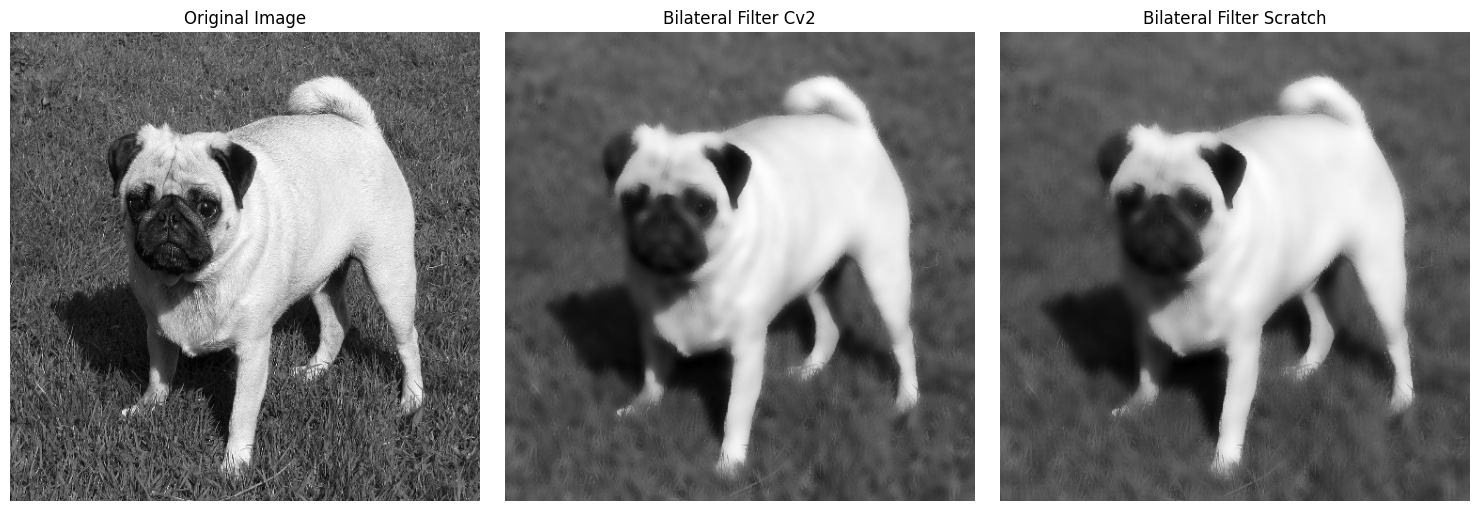

In [3]:
image_path = 'images/Image2.jpg'
L_image = cv2.imread(image_path)
L_image = cv2.resize(L_image, (500,500))
image = cv2.cvtColor(L_image, cv2.COLOR_BGR2GRAY)

print(f"Height: {image.shape[0]}, Width: {image.shape[1]}, Channels: {image.shape[2] if len(image.shape) > 2 else 1}")

filtered_image_OpenCV = cv2.bilateralFilter(image, 15, 75.0, 75.0)
filtered_image_Scratch = myfunc.bilateral_filter_scratch(image, 15, 75.0, 75.0)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  

# Plot Original
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')

# Plot filtro do OpenCV
axs[1].imshow(filtered_image_OpenCV, cmap='gray')
axs[1].set_title('Bilateral Filter Cv2')
axs[1].axis('off')

# Plot filtro próprio
axs[2].imshow(filtered_image_Scratch, cmap='gray')
axs[2].set_title('Bilateral Filter Scratch')
axs[2].axis('off')

plt.tight_layout()
plt.show()

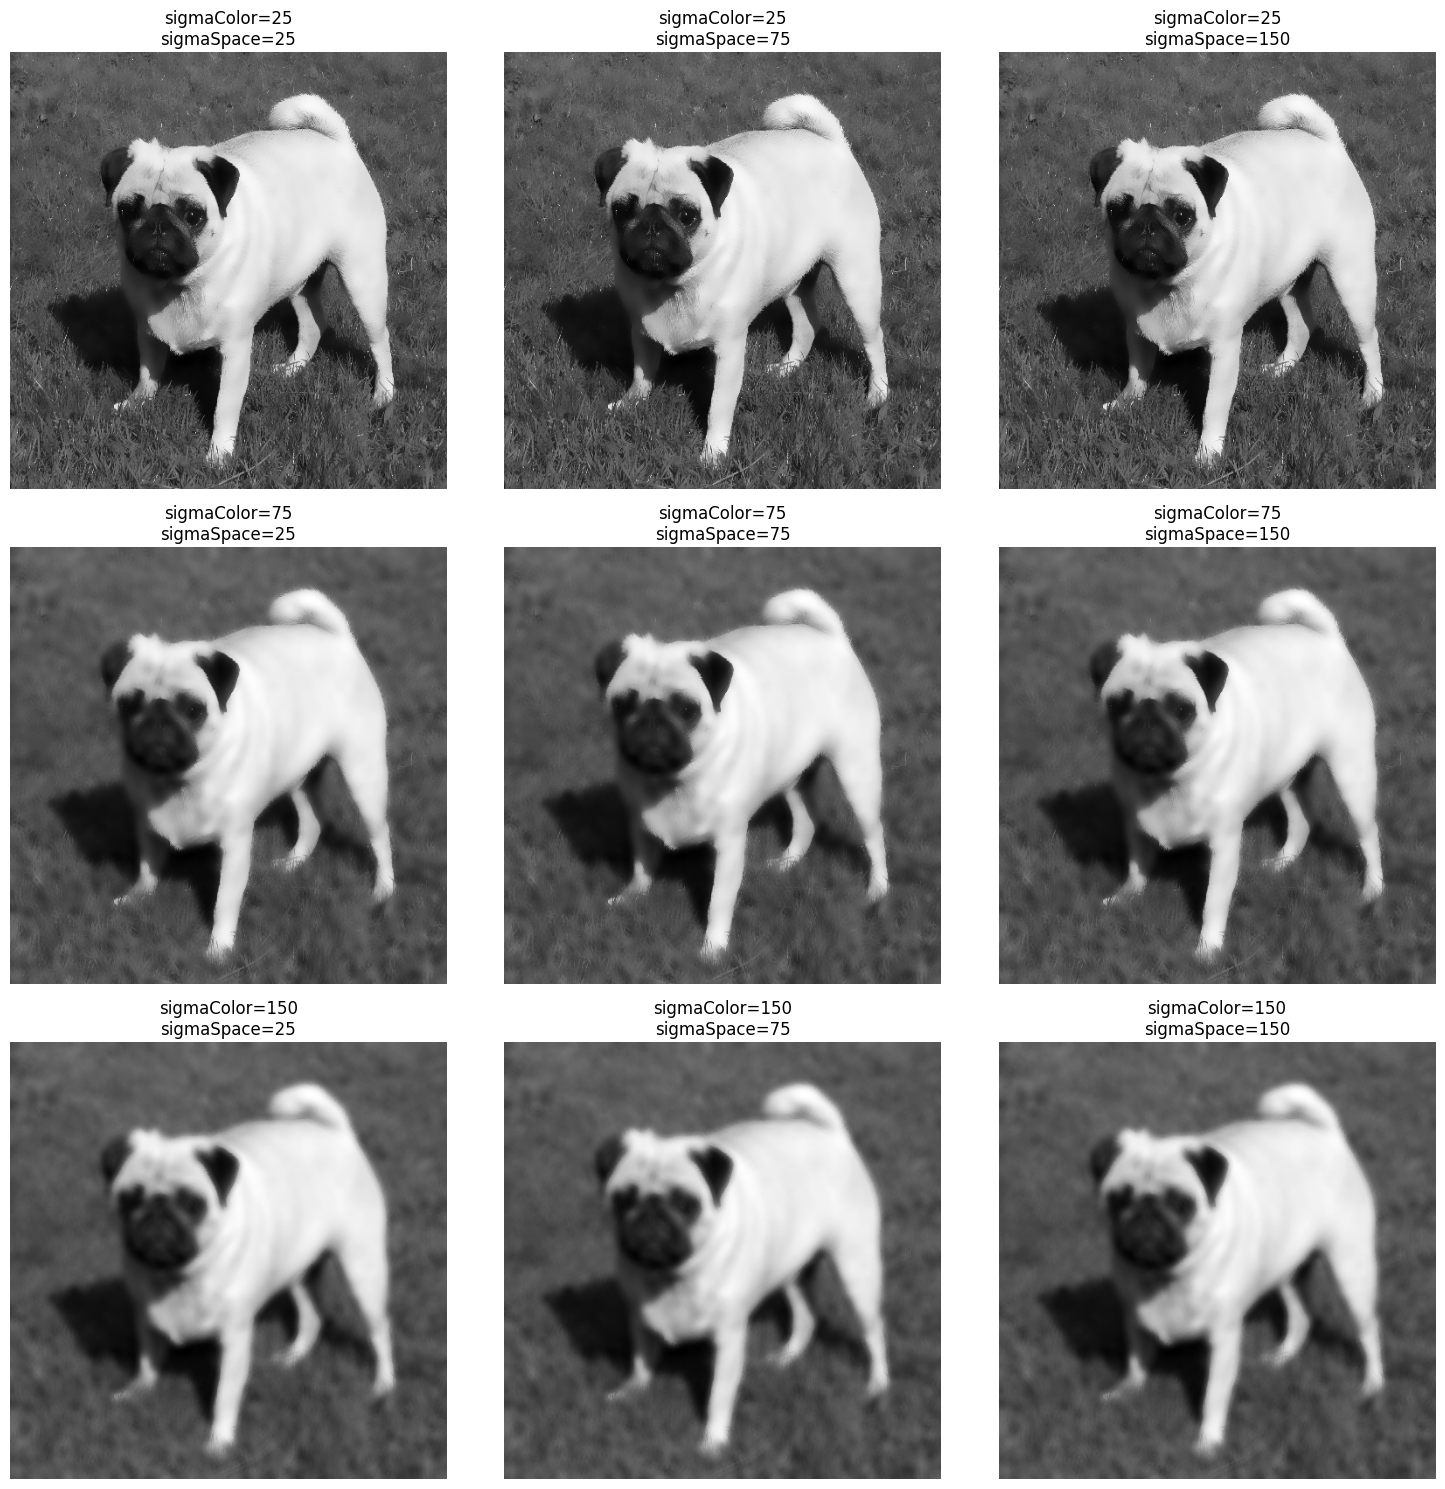

In [4]:
sigma_colors = [25, 75, 150]
sigma_spaces = [25, 75, 150]

fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for i, sigma_color in enumerate(sigma_colors):
    for j, sigma_space in enumerate(sigma_spaces):
        filtered = cv2.bilateralFilter(image, d=15, sigmaColor=sigma_color, sigmaSpace=sigma_space)
        
        ax = axs[i, j]
        ax.imshow(filtered, cmap='gray')
        ax.set_title(f'sigmaColor={sigma_color}\nsigmaSpace={sigma_space}')
        ax.axis('off')

plt.tight_layout()
plt.show()

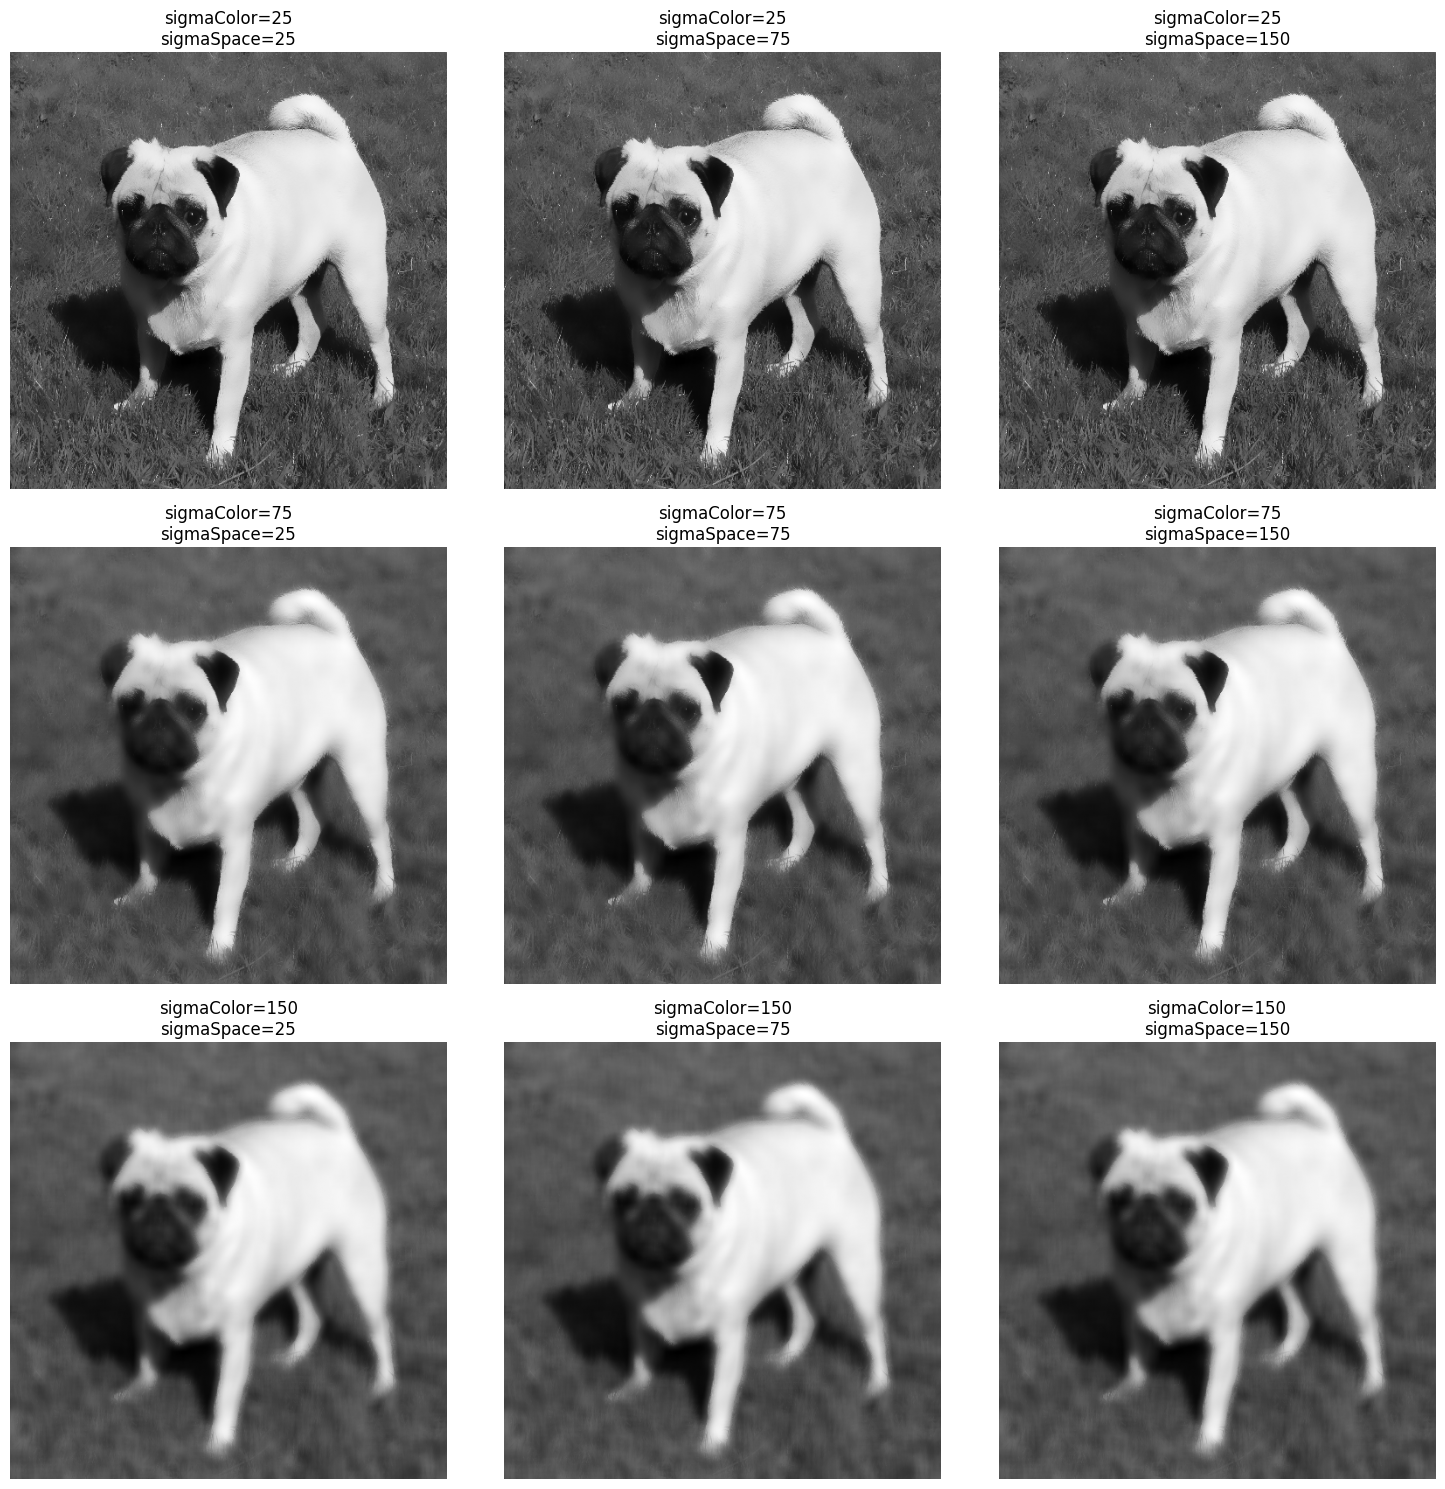

In [5]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for i, sigma_color in enumerate(sigma_colors):
    for j, sigma_space in enumerate(sigma_spaces):
        filtered = myfunc.bilateral_filter_scratch(image, 15, sigma_color, sigma_space)
        
        ax = axs[i, j]
        ax.imshow(filtered, cmap='gray')
        ax.set_title(f'sigmaColor={sigma_color}\nsigmaSpace={sigma_space}')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
def compare_filters(image, d, sigma_values):
    results = {
        'bilateral': [],
        'gaussian': []
    }

    for sigma in sigma_values:
        # Bilateral filter (sigmaColor = sigmaSpace = sigma)
        filtered_bilat = myfunc.bilateral_filter_scratch(image, d, sigma, sigma)
        mse_bilat = mean_squared_error(image, filtered_bilat)
        psnr_bilat = peak_signal_noise_ratio(image, filtered_bilat, data_range=255)
        ssim_bilat = structural_similarity(image, filtered_bilat, data_range=255)

        results['bilateral'].append({
            'sigma': sigma,
            'mse': mse_bilat,
            'psnr': psnr_bilat,
            'ssim': ssim_bilat
        })

        # Gaussian filter
        # ksize deve ser ímpar e igual a d
        filtered_gauss = cv2.GaussianBlur(image, (d, d), sigmaX=sigma)
        mse_gauss = mean_squared_error(image, filtered_gauss)
        psnr_gauss = peak_signal_noise_ratio(image, filtered_gauss, data_range=255)
        ssim_gauss = structural_similarity(image, filtered_gauss, data_range=255)

        results['gaussian'].append({
            'sigma': sigma,
            'mse': mse_gauss,
            'psnr': psnr_gauss,
            'ssim': ssim_gauss
        })

    return results
        

In [7]:
d = 15
sigma_values = [10, 25, 50, 75, 100, 150]

results = compare_filters(image, d, sigma_values)

# Mostrar resultados
print("Comparação Bilateral x Gaussian para diferentes valores de sigma (d=9):\n")

print("Bilateral Filter:")
for r in results['bilateral']:
    print(f"sigma={r['sigma']:>5} | MSE={r['mse']:.2f} | PSNR={r['psnr']:.2f} | SSIM={r['ssim']:.4f}")

print("\nGaussian Filter:")
for r in results['gaussian']:
    print(f"sigma={r['sigma']:>5} | MSE={r['mse']:.2f} | PSNR={r['psnr']:.2f} | SSIM={r['ssim']:.4f}")



Comparação Bilateral x Gaussian para diferentes valores de sigma (d=9):

Bilateral Filter:
sigma=   10 | MSE=12.98 | PSNR=37.00 | SSIM=0.9633
sigma=   25 | MSE=108.67 | PSNR=27.77 | SSIM=0.7934
sigma=   50 | MSE=277.51 | PSNR=23.70 | SSIM=0.5399
sigma=   75 | MSE=375.27 | PSNR=22.39 | SSIM=0.4207
sigma=  100 | MSE=435.63 | PSNR=21.74 | SSIM=0.3615
sigma=  150 | MSE=500.20 | PSNR=21.14 | SSIM=0.3088

Gaussian Filter:
sigma=   10 | MSE=562.91 | PSNR=20.63 | SSIM=0.2637
sigma=   25 | MSE=572.57 | PSNR=20.55 | SSIM=0.2597
sigma=   50 | MSE=573.52 | PSNR=20.55 | SSIM=0.2595
sigma=   75 | MSE=573.52 | PSNR=20.55 | SSIM=0.2595
sigma=  100 | MSE=573.52 | PSNR=20.55 | SSIM=0.2595
sigma=  150 | MSE=573.52 | PSNR=20.55 | SSIM=0.2595


para d = 9

Bilateral Filter:
sigma=   10 | MSE=3.16 | PSNR=43.13 | SSIM=0.9832
sigma=   25 | MSE=14.34 | PSNR=36.57 | SSIM=0.9588
sigma=   50 | MSE=35.60 | PSNR=32.62 | SSIM=0.9317
sigma=   75 | MSE=53.95 | PSNR=30.81 | SSIM=0.9159
sigma=  100 | MSE=68.17 | PSNR=29.79 | SSIM=0.9063
sigma=  150 | MSE=85.33 | PSNR=28.82 | SSIM=0.8965

Gaussian Filter:
sigma=   10 | MSE=104.33 | PSNR=27.95 | SSIM=0.8874
sigma=   25 | MSE=106.56 | PSNR=27.85 | SSIM=0.8858
sigma=   50 | MSE=106.56 | PSNR=27.85 | SSIM=0.8858
sigma=   75 | MSE=106.56 | PSNR=27.85 | SSIM=0.8858
sigma=  100 | MSE=106.56 | PSNR=27.85 | SSIM=0.8858
sigma=  150 | MSE=106.56 | PSNR=27.85 | SSIM=0.8858

## Isotropic diffusion

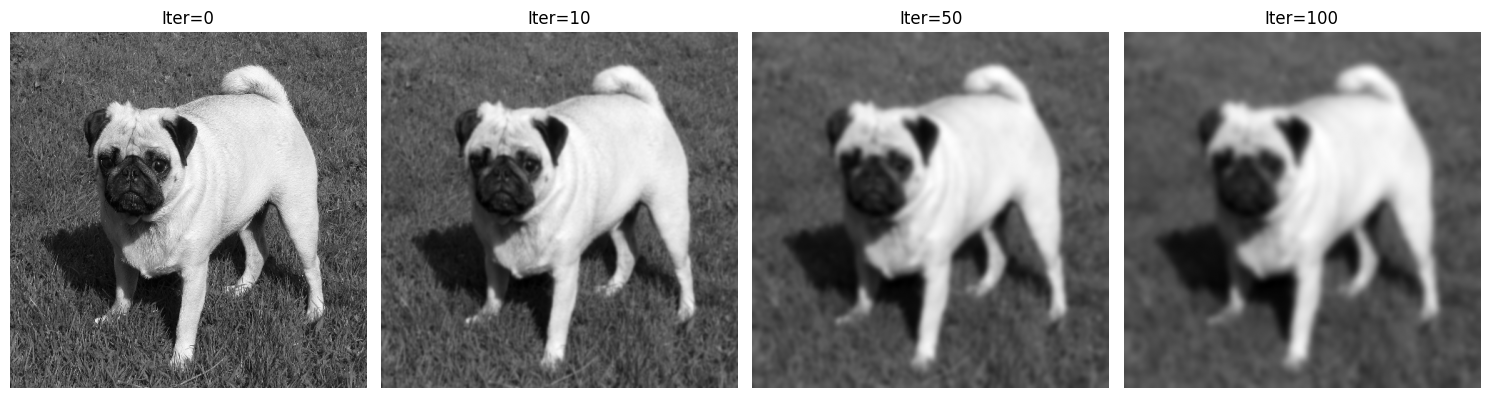

In [8]:
n_iters = [0, 10, 50, 100]

fig, axs = plt.subplots(1, 4, figsize=(15, 15))

for i, n_iter in enumerate(n_iters):
    filtered = myfunc.isotropic_diffusion(image, n_iter)
    
    ax = axs[i]
    ax.imshow(filtered, cmap='gray')
    ax.set_title(f'Iter={n_iter}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Anisotropic diffusion

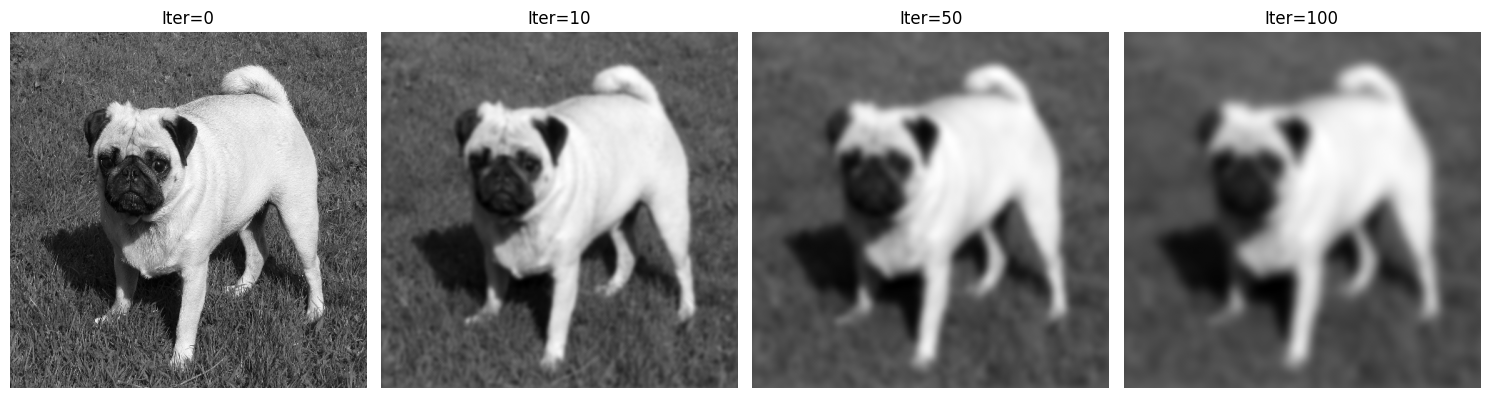

In [9]:
n_iters = [0, 10, 50, 100]

fig, axs = plt.subplots(1, 4, figsize=(15, 15))

for i, n_iter in enumerate(n_iters):
    filtered = myfunc.anisotropic_diffusion(image, n_iter)
    
    ax = axs[i]
    ax.imshow(filtered, cmap='gray')
    ax.set_title(f'Iter={n_iter}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Deep Image Prior (DIP)